In [1]:
# Grundläggande bibliotek
import time
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Förtränad modell och rätt preprocessing för MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Utvärdering
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

project_dir = pathlib.Path.cwd()

data_root = project_dir / "data"
data_root.mkdir(exist_ok=True)

archive_path = tf.keras.utils.get_file(
    fname="flower_photos.tgz",
    origin=dataset_url,
    cache_dir=str(project_dir),
    cache_subdir="data",
    extract=True
)

archive_path = pathlib.Path(archive_path)

candidate_dir = [
    path for path in data_root.rglob("flower_photos")
    if path.is_dir()
]

data_dir = None

for candidate in candidate_dir:
    image_count = len(list(candidate.glob("*/*.jpg")))

    if image_count > 0:
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError(
        "Hittade ingen flower_photos-mapp med bilder. "
        "Kontrollera att nedladdningen och uppackningen fungerade."
    )

image_count = len(list(data_dir.glob("*/*.jpg")))

print("Projektmapp:")
print(project_dir)

print("\n Nedladdad fil:")
print(archive_path)

print("\nData-mapp:")
print(data_root)

print("\nSökväg till bildmappen som ska användas:")
print(data_dir)

print("\nAntal bilder:")
print(image_count)

Projektmapp:
c:\Users\joaki\Desktop\DL_kurs

 Nedladdad fil:
c:\Users\joaki\Desktop\DL_kurs\data\flower_photos_extracted

Data-mapp:
c:\Users\joaki\Desktop\DL_kurs\data

Sökväg till bildmappen som ska användas:
c:\Users\joaki\Desktop\DL_kurs\data\flower_photos_extracted\flower_photos

Antal bilder:
3670


In [7]:
class_names_from_folders = sorted(
    [folder.name for folder in data_dir.iterdir() if folder.is_dir()]
)

print("Klasser från mapparna:")

for class_name in class_names_from_folders:
    class_folder = data_dir / class_name
    n_images = len(list(class_folder.glob("*.jpg")))
    print(f"- {class_name}: {n_images} bilder")

Klasser från mapparna:
- daisy: 633 bilder
- dandelion: 898 bilder
- roses: 641 bilder
- sunflowers: 699 bilder
- tulips: 799 bilder


In [8]:
img_size = (160, 160)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Klassnamn från train_ds:")
print(class_names)

print("\nAntal klasser:")
print(num_classes)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Klassnamn från train_ds:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Antal klasser:
5


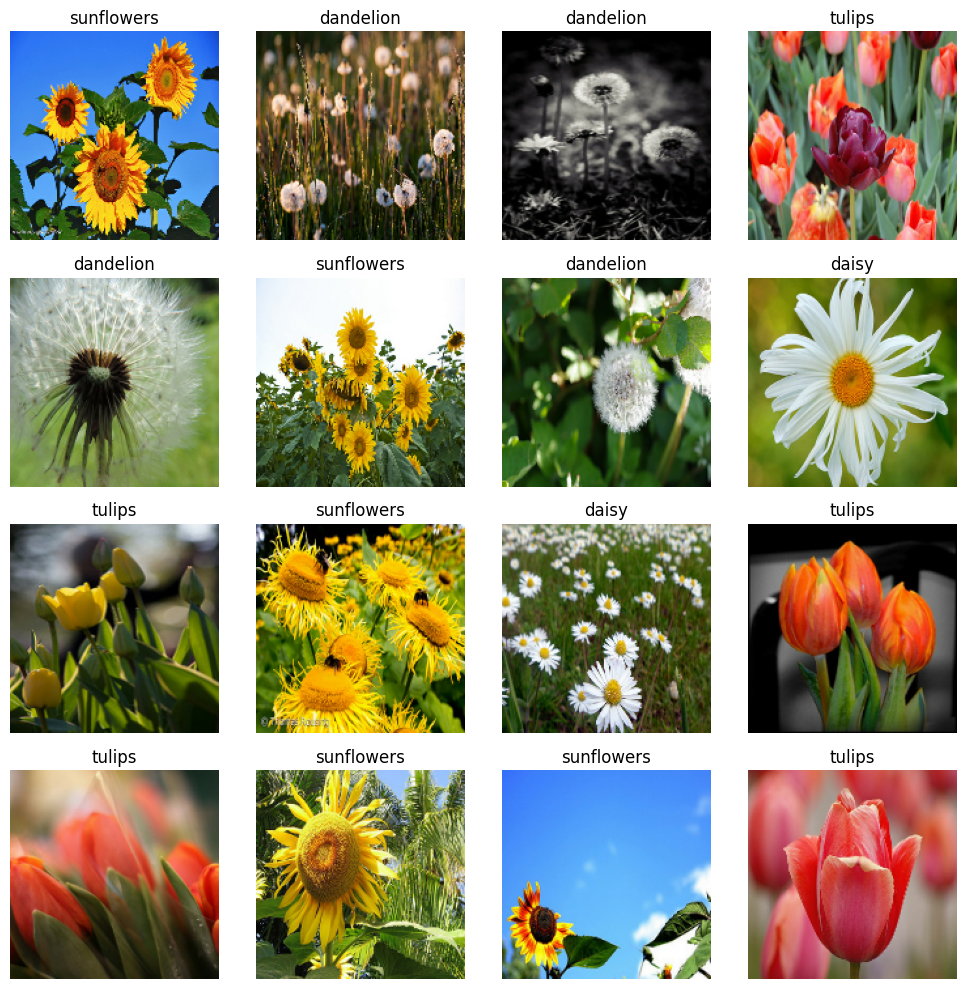

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(16):
        plt.subplot(4, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [11]:
def plot_history(history, title="Träningskurvor"):
    
    history_df = pd.DataFrame(history.history)
    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [13]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Antal lager i basmodellen:", len(base_model.layers))
print("Är basmodellen träningsbar?", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Antal lager i basmodellen: 154
Är basmodellen träningsbar? False


In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10)
], name = "data_augmentation")

inputs = keras.Input(shape=(160, 160, 3), name="input_image")

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

x = layers.Dropout(0.30, name="dropout")(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="predictions"
)(x)

transfer_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="transfer_learning_model"
)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "transfer_learning_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.6437 - loss: 0.9554 - val_accuracy: 0.8052 - val_loss: 0.5168
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8154 - loss: 0.5132 - val_accuracy: 0.8324 - val_loss: 0.4674
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8518 - loss: 0.4020 - val_accuracy: 0.8542 - val_loss: 0.4171
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8658 - loss: 0.3597 - val_accuracy: 0.8597 - val_loss: 0.4014
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8787 - loss: 0.3377 - val_accuracy: 0.8665 - val_loss: 0.3907
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.8896 - loss: 0.2983 - val_accuracy: 0.8488 - val_loss: 0.4271
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.8879 - loss: 0.3034 - val_accuracy: 0.8529 - val_loss: 0.4529
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9022 - loss: 0.2757 - val_accuracy: 0.8678 -

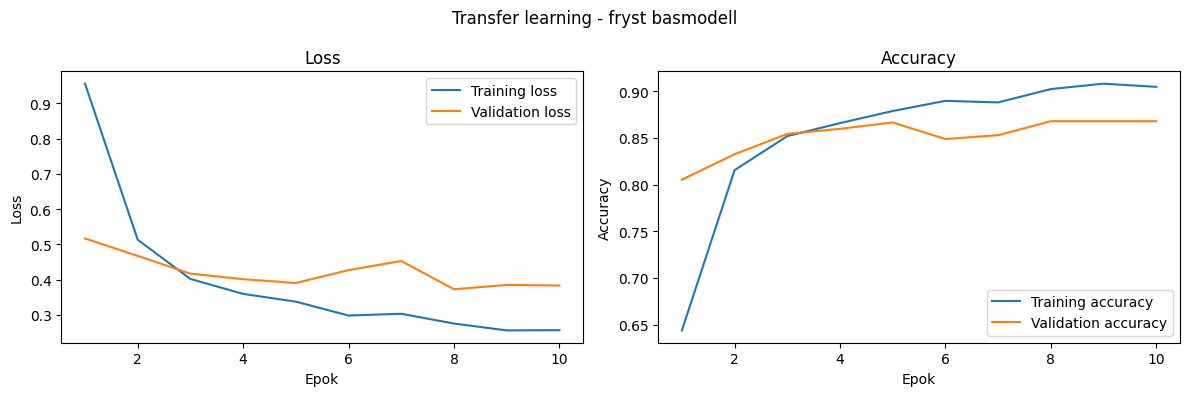

In [15]:
start_time = time.time()

history_head = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

head_training_time = time.time() - start_time

print(f"Träningstid för klassificeringshuvud: {head_training_time / 60:.2f} minuter")
plot_history(history_head, title="Transfer learning - fryst basmodell")

In [16]:
val_loss_head, val_accuracy_head = transfer_model.evaluate(
    val_ds,
    verbose=0
)

print(f"Validation loss med fryst basmodell: {val_loss_head:.4f}")
print(f"Validation accuracy med fryst basmodell: {val_accuracy_head:.4f}")

Validation loss med fryst basmodell: 0.3835
Validation accuracy med fryst basmodell: 0.8678


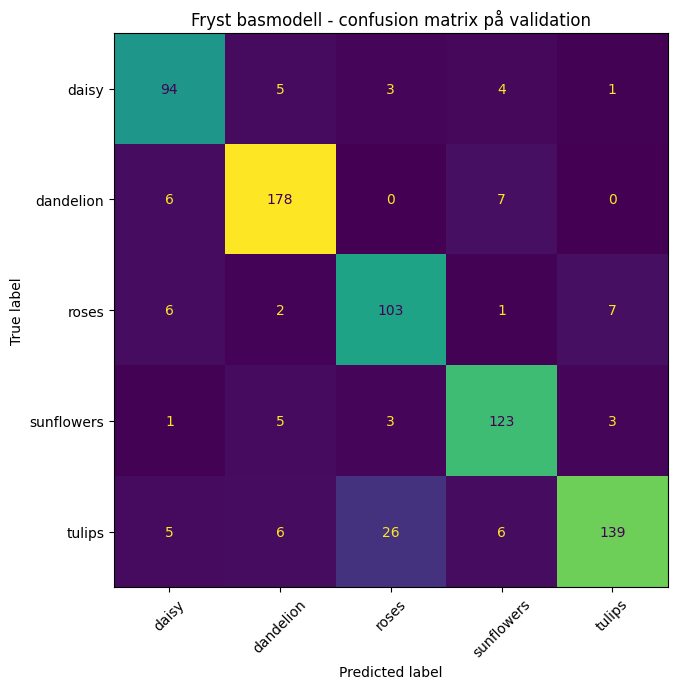

In [ ]:
def predict_from_dataset(model, dataset):
    """
    Gör prediktioner från ett tf.data-dataset och samlar sanna labels.

    model:
        Tränad Keras-modell.

    dataset:
        tf.data-dataset med (bilder, labels).

    Returnerar:
        y_true, y_pred, y_proba
    """

    y_true_batches = []
    y_proba_batches = []

    for batch_images, batch_labels in dataset:
        batch_proba = model.predict(batch_images, verbose=0)

        y_true_batches.append(batch_labels.numpy())
        y_proba_batches.append(batch_proba)

    y_true = np.concatenate(y_true_batches)
    y_proba = np.concatenate(y_proba_batches)
    y_pred = np.argmax(y_proba, axis=1)

    return y_true, y_pred, y_proba


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):
    """
    Plottar en confusion matrix.
    """

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names))
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm


y_val_true, y_val_pred_head, y_val_proba_head = predict_from_dataset(
    transfer_model,
    val_ds
)

cm_head = plot_confusion_matrix(
    y_val_true,
    y_val_pred_head,
    class_names,
    title="Fryst basmodell - confusion matrix på validation"
)

In [18]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_layers = sum(layer.trainable for layer in base_model.layers)

print("Antal lager i basmodellen:", len(base_model.layers))
print("Antal träningsbara lager i basmodellen:", trainable_layers)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

Antal lager i basmodellen: 154
Antal träningsbara lager i basmodellen: 30


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.8229 - loss: 0.5008 - val_accuracy: 0.8706 - val_loss: 0.3843
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8668 - loss: 0.3656 - val_accuracy: 0.8692 - val_loss: 0.3785
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.8743 - loss: 0.3503 - val_accuracy: 0.8760 - val_loss: 0.3665
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.8822 - loss: 0.3213 - val_accuracy: 0.8828 - val_loss: 0.3580
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.8971 - loss: 0.2873 - val_accuracy: 0.8856 - val_loss: 0.3434
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9111 - loss: 0.2537 - val_accuracy: 0.8896 - val_loss: 0.3386
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9114 - loss: 0.2497 - val_accuracy: 0.8924 - val_loss: 0.3339
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9230 - loss: 0.2283 - val_accu

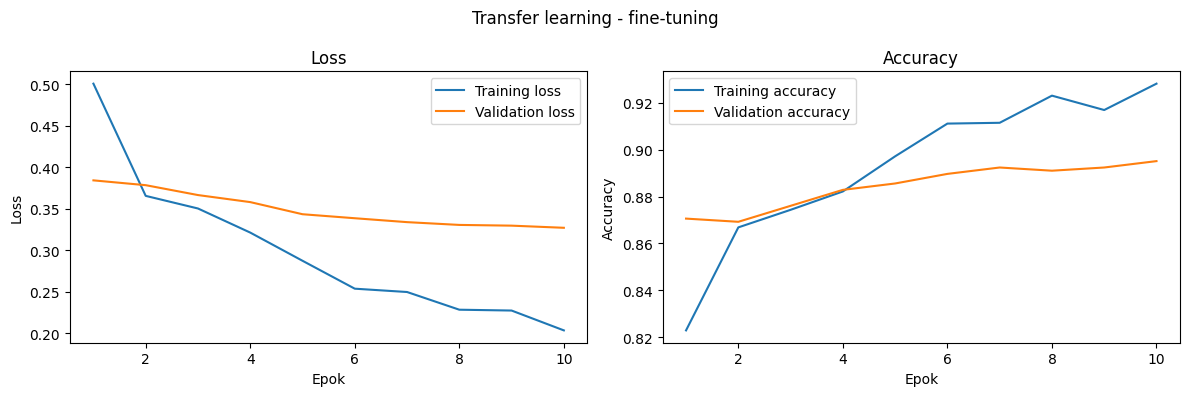

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

fine_tuning_time = time.time() - start_time

print(f"Träningstid för fine-tuning: {fine_tuning_time / 60:.2f} minuter")
plot_history(history_fine, title="Transfer learning - fine-tuning")

In [21]:
val_loss_fine, val_accuracy_fine = transfer_model.evaluate(
    val_ds,
    verbose=0
)

comparison = pd.DataFrame([
    {
        "modell": "Fryst basmodell",
        "val_loss": val_loss_head,
        "val_accuracy": val_accuracy_head
    },
    {
        "modell": "Efter fine-tuning",
        "val_loss": val_loss_fine,
        "val_accuracy": val_accuracy_fine
    }
])

comparison

,modell,val_loss,val_accuracy
0,Fryst basmodell,0.383482,0.867847
1,Efter fine-tuning,0.327075,0.895095


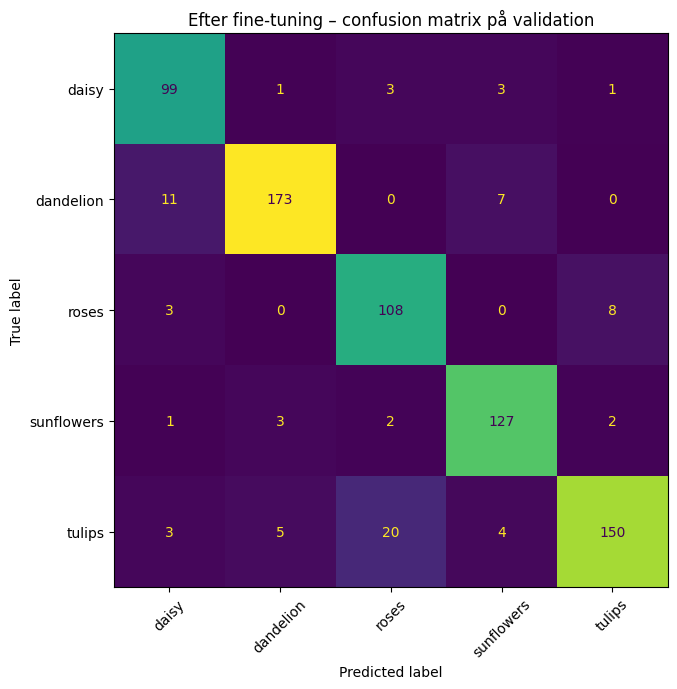

In [22]:
y_val_true, y_val_pred_fine, y_val_proba_fine = predict_from_dataset(
    transfer_model,
    val_ds
)

cm_fine = plot_confusion_matrix(
    y_val_true,
    y_val_pred_fine,
    class_names,
    title="Efter fine-tuning – confusion matrix på validation"
)

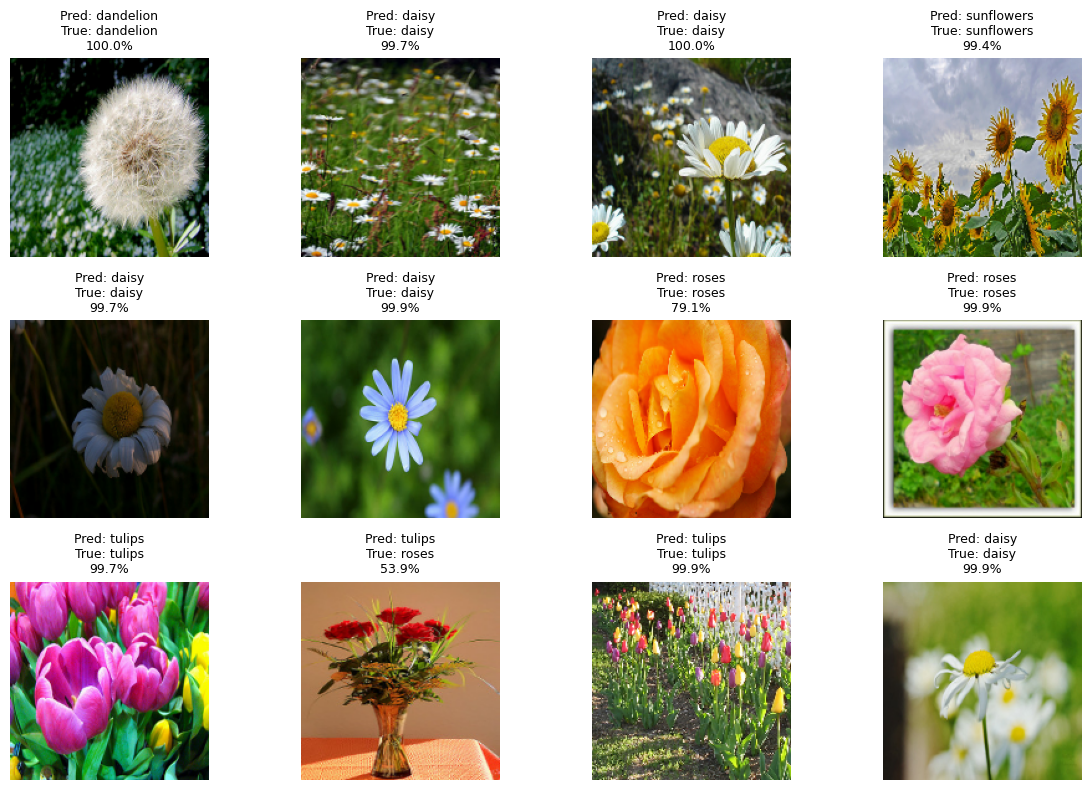

In [23]:
plt.figure(figsize=(12, 8))

for images, labels in val_ds.take(1):
    probabilities = transfer_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    for i in range(12):
        confidence = probabilities[i, predictions[i]] * 100

        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Pred: {class_names[predictions[i]]}\n"
            f"True: {class_names[labels[i].numpy()]}\n"
            f"{confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
transfer_model.save("flower_transfer_learning_mobilenetv2.keras")